original data shape: (524288, 512)
number of frequencies: 512
dt: 0.0019660800000000003 s
transposing data
data shape after possible transpose: (512, 524288)
cropped data shape: (512, 15259)
cropped duration: 29.998448640000003 s
making plot...


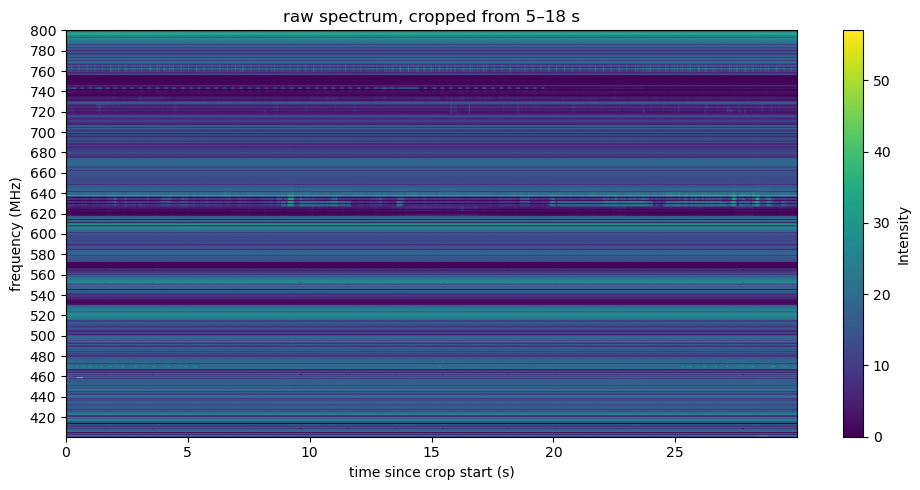

done


In [75]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import os

os.chdir("/Users/alana/Desktop/anaconda")

path = "/Users/alana/Desktop/anaconda/335.13_48.05_60195.29196.npy"

data = np.load(path)

tsamp = 2 * 0.98304 * u.ms
dt = tsamp.to(u.s).value

frequencies = np.linspace(800, 400, 512, endpoint=False) * u.MHz
freqs_mhz = frequencies.to(u.MHz).value

print("original data shape:", data.shape)
print("number of frequencies:", len(frequencies))
print("dt:", dt, "s")

# Make sure data has shape (n_freq, n_time)
if data.shape[1] == len(frequencies):
    print("transposing data")
    data = data.T

print("data shape after possible transpose:", data.shape)

# Crop original data
start_sec = 5.0
end_sec = 35.0 #18.0

start_idx = int(round(start_sec / dt))
end_idx = int(round(end_sec / dt))

data = data[:, start_idx:end_idx]

n_freq, n_time = data.shape

# Relative time axis for cropped data
times_s = np.arange(n_time) * dt

# Absolute time axis to know where this came from in original 
times_abs_s = times_s + start_sec

print("cropped data shape:", data.shape)
print("cropped duration:", times_s[-1], "s")

print("making plot...")

plt.figure(figsize=(10, 5))
plt.imshow(
    data,
    aspect="auto",
    origin="upper",
    extent=[times_s[0], times_s[-1], np.min(freqs_mhz), np.max(freqs_mhz)]
)
plt.xlabel("time since crop start (s)")
plt.ylabel("frequency (MHz)")
plt.locator_params(axis="y", nbins=20)
plt.title("raw spectrum, cropped from 5–18 s")
plt.colorbar(label="Intensity")
plt.tight_layout()
plt.savefig("cropped3_rawspec_335.png", dpi=300)
plt.show()

print("done")

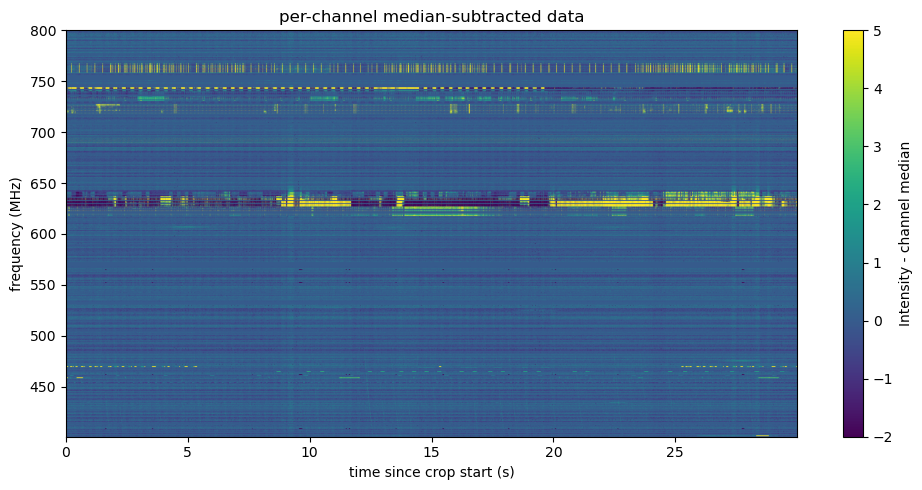

number bad channels: 131
number bad times: 3896
fraction masked: 0.25693712010125175


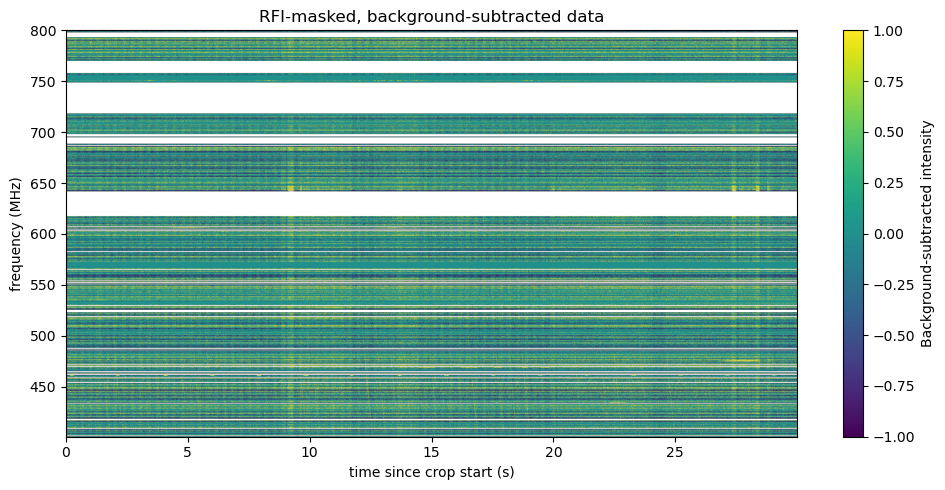

In [76]:
# REMOVE BACKGROUND PER FREQUENCY CHANNEL

# Median intensity per frequency channel over time
freq_med = np.nanmedian(data, axis=1, keepdims=True)

# Background-subtracted data NOT divide by std/MAD - in intensity units.
data_sub_back = data - freq_med


# PLOT BACKGROUND-SUBTRACTED DATA


plt.figure(figsize=(10, 5))
plt.imshow(
    data_sub_back,
    aspect="auto",
    origin="upper",
    extent=[times_s[0], times_s[-1], np.min(freqs_mhz), np.max(freqs_mhz)],
    vmin=np.nanpercentile(data_sub_back, 1),
    vmax=np.nanpercentile(data_sub_back, 99)
)
plt.xlabel("time since crop start (s)")
plt.ylabel("frequency (MHz)")
plt.title("per-channel median-subtracted data")
plt.colorbar(label="Intensity - channel median")
plt.tight_layout()
plt.savefig("cropped3_background_subtracted_335.png", dpi=300)
plt.show()



# RFI MASKING WITHOUT EARLY Z-SCORING


# Pixel-level mask 
# (replaces np.abs(z) > 3)
med_global = np.nanmedian(data_sub_back)
mad_global = np.nanmedian(np.abs(data_sub_back - med_global))
sigma_global = 1.4826 * mad_global

if not np.isfinite(sigma_global) or sigma_global <= 0:
    sigma_global = np.nanstd(data_sub_back)

if not np.isfinite(sigma_global) or sigma_global <= 0:
    raise ValueError("Could not estimate scatter for pixel masking.")

pixel_mask = np.abs(data_sub_back - med_global) > 1 * sigma_global  #5?


# freq-channel mask
chan_power = np.nanstd(data_sub_back, axis=1)
chan_med = np.nanmedian(chan_power)
chan_mad = np.nanmedian(np.abs(chan_power - chan_med))
chan_sigma = 1.4826 * chan_mad

if not np.isfinite(chan_sigma) or chan_sigma <= 0:
    chan_sigma = np.nanstd(chan_power)

bad_channels = chan_power > chan_med + 0.75 * chan_sigma

# manually mask bad freq ranges
manual_bad_freqs = (
    ((freqs_mhz >= 620) & (freqs_mhz <= 640)) |
    ((freqs_mhz >= 720) & (freqs_mhz <= 748)) |
    ((freqs_mhz >= 760) & (freqs_mhz <= 770))
)

# combine freq masks
bad_channels = bad_channels | manual_bad_freqs


# Time-sample mask
time_power = np.nanstd(data_sub_back, axis=0)
time_med = np.nanmedian(time_power)
time_mad = np.nanmedian(np.abs(time_power - time_med))
time_sigma = 1.4826 * time_mad

if not np.isfinite(time_sigma) or time_sigma <= 0:
    time_sigma = np.nanstd(time_power)

bad_times = time_power > time_med + 1 * time_sigma


# Combine into 2D RFI mask
rfi_mask = pixel_mask.copy()
rfi_mask[bad_channels, :] = True
#rfi_mask[:, bad_times] = True


# Apply mask
data_masked = data_sub_back.copy()
data_masked[rfi_mask] = np.nan


print("number bad channels:", np.sum(bad_channels))
print("number bad times:", np.sum(bad_times))
print("fraction masked:", np.mean(rfi_mask))



# PLOT RFI-MASKED BACKGROUND-SUBTRACTED DATA


plt.figure(figsize=(10, 5))
plt.imshow(
    data_masked,
    aspect="auto",
    origin="upper",
    extent=[times_s[0], times_s[-1], np.min(freqs_mhz), np.max(freqs_mhz)],
    vmin=np.nanpercentile(data_masked, 1),
    vmax=np.nanpercentile(data_masked, 99)
)
plt.xlabel("time since crop start (s)")
plt.ylabel("frequency (MHz)")
plt.title("RFI-masked, background-subtracted data")
plt.colorbar(label="Background-subtracted intensity")
plt.tight_layout()
plt.savefig("cropped3_masked_background_subtracted_335.png", dpi=300)
plt.show()

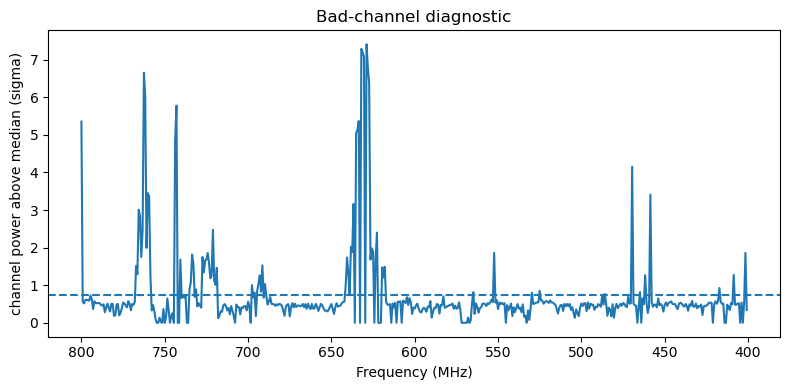

In [77]:
# Sigma diagnostic

chan_z = (chan_power - chan_med) / chan_sigma

plt.figure(figsize=(8, 4))
plt.plot(freqs_mhz, chan_power)
plt.axhline(0.75, linestyle="--")    # 1 sigma is ideal?
plt.xlabel("Frequency (MHz)")
plt.ylabel("channel power above median (sigma)")
plt.title("Bad-channel diagnostic")
plt.gca().invert_xaxis()
plt.tight_layout()
plt.savefig("bad-chan_diagnostic.png")
plt.show()

/var/folders/h8/1hsc6dd542v8gpmdh1wgtl3c0000gn/T/ipykernel_35434/3321847506.py:55: RuntimeWarning: Mean of empty slice
  t_series = np.nanmean(dedisp, axis=0)


(201, 15259)
best dm: 43
best snr: 10.629251700680275


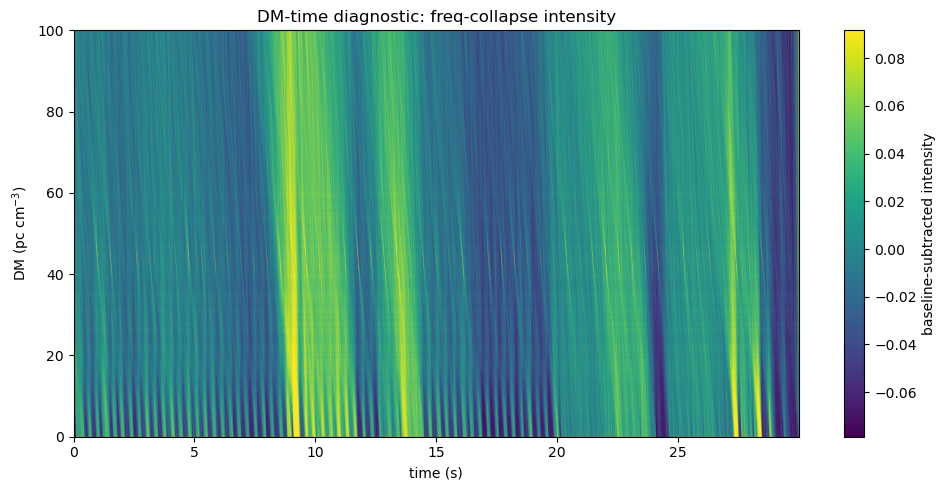

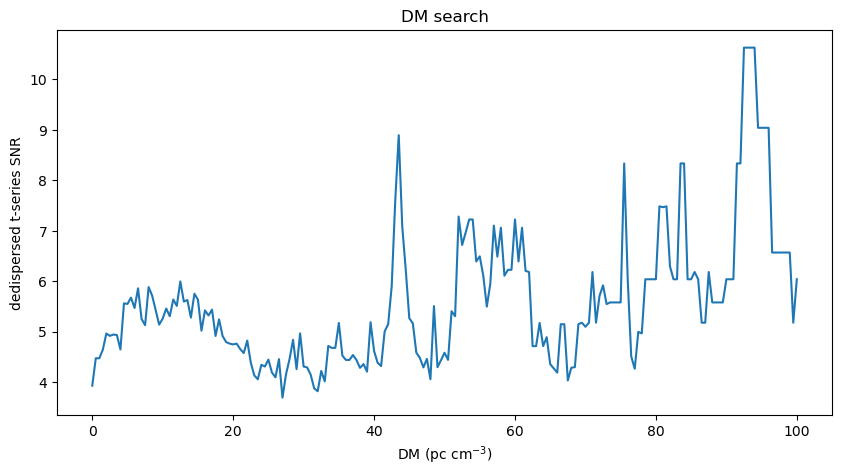

In [78]:
freqs_mhz_original = freqs_mhz.copy()
freqs_mhz_reversed = freqs_mhz[::-1].copy()
plot_extent = [times_s[0], times_s[-1], np.min(freqs_mhz), np.max(freqs_mhz)]

#freqs_mhz = freqs_mhz_reversed
ref_freq = np.max(freqs_mhz)
k = 4149.4 # secs * MHz^2 * pc^-1 cm^3



def dedisperse(data, freqs_mhz, DM, dt, ref_freq): # incoherent dedispersion --> data shape: (n_freq, n_time)

    n_freq, n_time = data.shape
    dedispersed = np.full_like(data, np.nan, dtype=float)
    delta_t = k * DM * (freqs_mhz**-2 - ref_freq**-2)
    t_bins = np.rint(delta_t / dt).astype(int)

    for i in range(n_freq):
        shift = t_bins[i]

        if shift > 0:
            dedispersed[i, :-shift] = data[i, shift:]
            dedispersed[i, -shift:] = np.nan
        elif shift < 0:
            dedispersed[i, -shift:] = data[i, :shift]
            dedispersed[i, :-shift] = np.nan
        else:
            dedispersed[i, :] = data[i, :]
    
    return dedispersed, t_bins


def t_series_1D(dedispersed):
    return np.nanmean(dedispersed, axis=0)

def snr(time_series):
    med = np.nanmedian(time_series)
    mad = np.nanmedian(np.abs(time_series-med))
    sigma = 1.4826 * mad

    if sigma == 0 or np.isnan(sigma):
        return np.nan
    
    return (np.nanmax(time_series)-med) / sigma


DM_span = np.linspace(0,100,201)   #181 pts from 10 to 100
#test_DMs = [36, 42, 43, 45, 48, 54]

I_dm_time = []
snrs = []

for DM in DM_span:
    dedisp, shifts = dedisperse(data_masked, freqs_mhz, DM, dt, ref_freq)
    t_series = np.nanmean(dedisp, axis=0)
    
    #valid_per_time = np.sum(np.isfinite(dedisp), axis=0)

    #t_series = np.full(dedisp.shape[1], np.nan)

    #good_times = valid_per_time > 0
    #t_series[good_times] = np.nanmean(dedisp[:, good_times], axis=0)

    t_series = t_series - np.nanmedian(t_series)


    I_dm_time.append(t_series)
    snrs.append(snr(t_series))

I_dm_time = np.array(I_dm_time)
snrs = np.array(snrs)
print(I_dm_time.shape)

best_dm = 43 #DM_span[np.nanargmax(snrs)]
best_snr = np.nanmax(snrs)
print(f"best dm: {best_dm}")
print(f"best snr: {best_snr}")

plt.figure(figsize=(10,5))
plt.imshow(
    I_dm_time,
    aspect="auto",
    origin="lower",
    extent=[times_s[0], times_s[-1], DM_span[0], DM_span[-1]],
    vmin=np.nanpercentile(I_dm_time, 1), # limits below 1% and over 99% (crop) 
    vmax=np.nanpercentile(I_dm_time, 99)
)

plt.xlabel("time (s)")
plt.ylabel("DM (pc cm$^{-3}$)")
plt.title("DM-time diagnostic: freq-collapse intensity")
plt.colorbar(label="baseline-subtracted intensity")
plt.tight_layout()
plt.savefig("DM-time_diagnostic.png", dpi=300)
plt.show()


plt.figure(figsize=(10,5))
plt.plot(DM_span, snrs)
plt.xlabel("DM (pc cm$^{-3}$)")
plt.ylabel("dedispersed t-series SNR")
plt.title("DM search")
plt.savefig("dm_search.png", dpi=300)
plt.show()



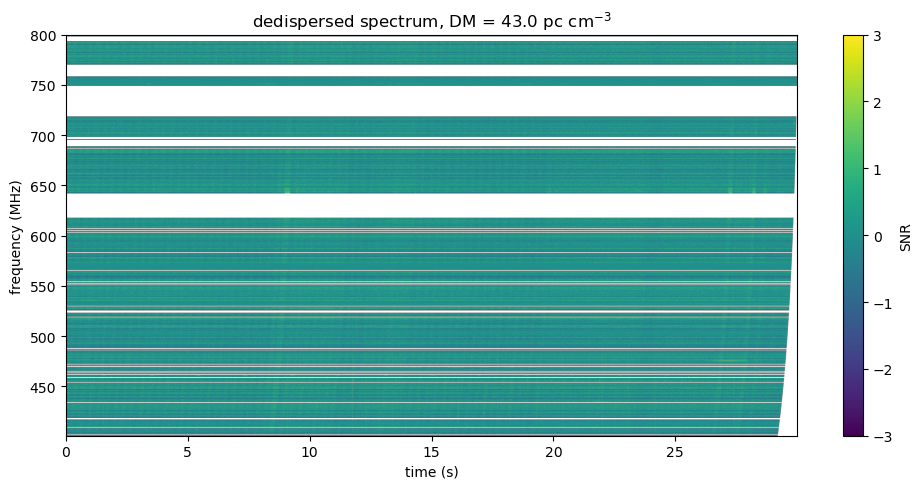

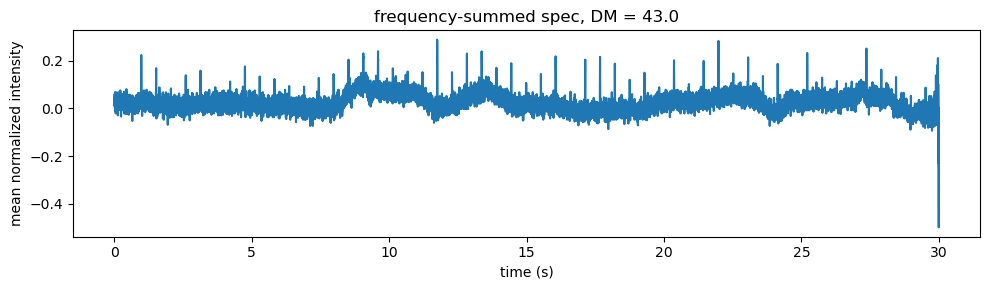

In [79]:
# dedispersed at best DM plot

dedisp_best, shifts_best = dedisperse(data_masked, freqs_mhz, best_dm, dt, ref_freq=ref_freq)
t_series_best = t_series_1D(dedisp_best)
plt.figure(figsize=(10, 5))
plt.imshow(
    dedisp_best,
    aspect="auto",
    origin="upper",
    vmin=-3,
    vmax=3,
    extent=plot_extent
)
plt.xlabel("time (s)")
plt.ylabel("frequency (MHz)")
plt.title(f"dedispersed spectrum, DM = {best_dm:.1f} pc cm$^{{-3}}$")
plt.colorbar(label="SNR")
plt.tight_layout()
plt.savefig("dedispersed_spec.png", dpi=300)
plt.show()


# intensity plot
times_plot_s = np.arange(len(t_series_best)) * dt

plt.figure(figsize=(10, 3))
plt.plot(times_plot_s, t_series_best)
plt.xlabel("time (s)")
plt.ylabel("mean normalized intensity")
plt.title(f"frequency-summed spec, DM = {best_dm:.1f}")
plt.tight_layout()
plt.savefig("freq_summed_time_series", dpi=300)
plt.show()


power_dm_freq shape: (201, 7630)
freq_spin shape: (7630,)
freq min/max: 0.0 254.29648460539676
masked stacked spin bins: 97
fraction masked: 0.210412147505423
log threshold: 1.5


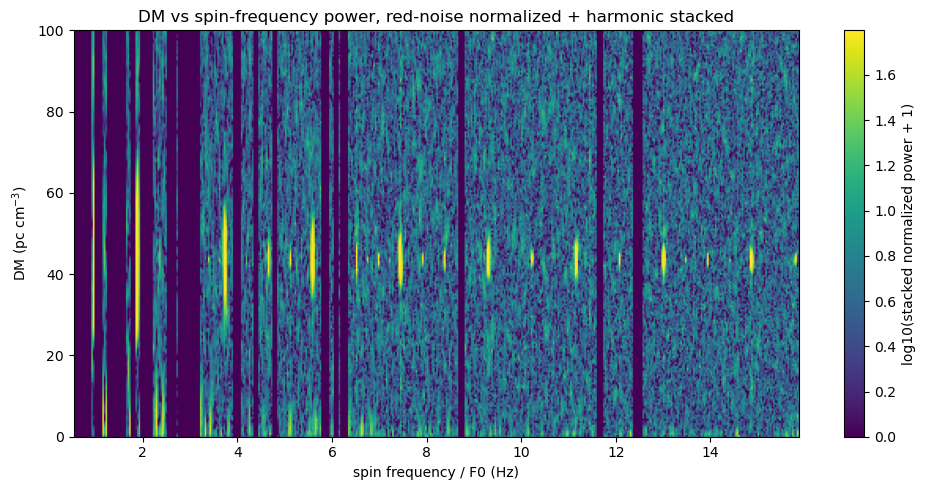

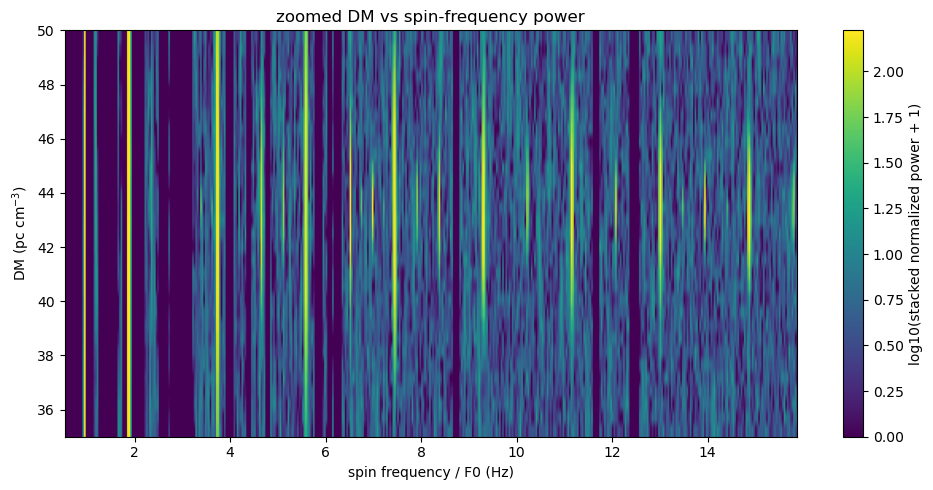

In [80]:
I_new = I_dm_time.copy()

#replace nans
for i in range(I_new.shape[0]): #time axis
    row = I_new[i]
    
    med = np.nanmedian(row)
    row = np.where(np.isnan(row), med, row) # now all nans gone
    row = row - np.median(row)  # go to 0 or row-med
    
    mad = np.median(np.abs(row-np.median(row)))
    sigma = 1.4826 * mad
    #if sigma != 0 and not np.isnan(sigma):
        #row = row / sigma
    
    I_new[i] = row


# try fft window? (HANNING!)
window = np.hanning(I_new.shape[1])
I_new = I_new * window

# FFT!
fft_dm = np.fft.rfft(I_new, axis=1)
freq_spin = np.fft.rfftfreq(I_new.shape[1], d=dt)
power_dm_freq = np.abs(fft_dm)**2

# remove DC
power_dm_freq[:, 0] = 0

print("power_dm_freq shape:", power_dm_freq.shape)
print("freq_spin shape:", freq_spin.shape)
print("freq min/max:", freq_spin[0], freq_spin[-1])

# red noise normalization

from scipy.ndimage import median_filter

bg_window = 101   # odd; try 51 or 101
eps = 1e-12

power_norm_full = np.zeros_like(power_dm_freq)

for i in range(power_dm_freq.shape[0]):
    row = power_dm_freq[i]

    # running-median background along frequency axis
    bg = median_filter(row, size=bg_window, mode="reflect")

    # subtract background
    excess = row - bg

    # robust scatter estimate from that excess
    med_excess = np.nanmedian(excess)
    mad_excess = np.nanmedian(np.abs(excess - med_excess))
    sigma_excess = 1.4826 * mad_excess

    if not np.isfinite(sigma_excess) or sigma_excess <= 0:
        sigma_excess = np.nanstd(excess)

    if not np.isfinite(sigma_excess) or sigma_excess <= 0:
        sigma_excess = 1.0

    row_norm = excess / (sigma_excess + eps)

    # keep only positive excess
    row_norm[row_norm < 0] = 0

    # remove any bad numeric values
    row_norm = np.nan_to_num(row_norm, nan=0.0, posinf=0.0, neginf=0.0)

    power_norm_full[i] = row_norm

# keep DC zero
power_norm_full[:, 0] = 0



#harmonic stacking

harmonics = [1, 2, 4, 8, 16]   
max_h = max(harmonics)

T_max = 2.0
T_min = 0.0039
f_min = 0.5
f_max_user = 100.0

# only fundamentals whose highest harmonic exists
f_max_stack = min(f_max_user, freq_spin[-1] / max_h)

base_freq_mask = (freq_spin >= f_min) & (freq_spin <= f_max_stack)
base_freq = freq_spin[base_freq_mask]

if np.sum(base_freq_mask) == 0:
    raise ValueError("base_freq_mask is empty") #check dt or harmonic list

power_harmonic_stack = np.zeros((power_norm_full.shape[0], len(base_freq)))

for h in harmonics:
    for i in range(power_norm_full.shape[0]):
        power_harmonic_stack[i] += np.interp(
            base_freq * h,
            freq_spin,
            power_norm_full[i],
            left=0,
            right=0
        )



# DM=0 RFI mask using log10 stacked normalized power

dm0_idx = np.argmin(np.abs(DM_span - 0))
plot_power = np.log10(power_harmonic_stack + 1)

# DM = 0 row
dm0_log_power = plot_power[dm0_idx].copy()

# threshold in log10(stacked power + 1)
log_threshold = 1.5

bad_base_spin_mask = dm0_log_power > log_threshold

# mask zero/DC 
#bad_base_spin_mask[0] = True

# widen mask by 1 neighbor bin?
from scipy.ndimage import binary_dilation
bad_base_spin_mask = binary_dilation(bad_base_spin_mask, iterations=1)

# mask all DMs in stacked result
power_harmonic_stack = power_harmonic_stack.copy()
power_harmonic_stack[:, bad_base_spin_mask] = 0

print("masked stacked spin bins:", np.sum(bad_base_spin_mask))
print("fraction masked:", np.mean(bad_base_spin_mask))
print("log threshold:", log_threshold)



# STACKED DM VS SPIN FREQ plot

plot_power = np.log10(power_harmonic_stack + 1)

vmin = np.nanpercentile(plot_power, 5)
vmax = np.nanpercentile(plot_power, 99.5)

plt.figure(figsize=(10, 5))
plt.imshow(
    plot_power,
    aspect="auto",
    origin="lower",
    extent=[
        base_freq[0],
        base_freq[-1],
        DM_span[0],
        DM_span[-1]
    ],
    vmin=vmin,
    vmax=vmax
)
plt.xlabel("spin frequency / F0 (Hz)")
plt.ylabel("DM (pc cm$^{-3}$)")
plt.title("DM vs spin-frequency power, red-noise normalized + harmonic stacked")
plt.colorbar(label="log10(stacked normalized power + 1)")
plt.tight_layout()
plt.savefig("harmonic_stack_3.png", dpi=300)
plt.show()



# ZOOMED PLOT


dm_min = 35
dm_max = 50

f_min2 = 0.5
f_max2 = min(80, base_freq[-1])

dm_mask = (DM_span >= dm_min) & (DM_span <= dm_max)
freq_mask2 = (base_freq >= f_min2) & (base_freq <= f_max2)

plt_power_zoom = np.log10(power_harmonic_stack[dm_mask][:, freq_mask2] + 1)

vmin_zoom = np.nanpercentile(plt_power_zoom, 5)
vmax_zoom = np.nanpercentile(plt_power_zoom, 99)

plt.figure(figsize=(10, 5))
plt.imshow(
    plt_power_zoom,
    aspect="auto",
    origin="lower",
    extent=[
        base_freq[freq_mask2][0],
        base_freq[freq_mask2][-1],
        DM_span[dm_mask][0],
        DM_span[dm_mask][-1]
    ],
    vmin=vmin_zoom,
    vmax=vmax_zoom
)
plt.xlabel("spin frequency / F0 (Hz)")
plt.ylabel("DM (pc cm$^{-3}$)")
plt.title("zoomed DM vs spin-frequency power")
plt.colorbar(label="log10(stacked normalized power + 1)")
plt.tight_layout()
plt.savefig("zoom_harmonic_stack_3.png", dpi=300)
plt.show()

In [87]:
import pandas as pd
from scipy.ndimage import maximum_filter

# find strongest NONZERO peak in one DM row (near target freq)
def local_peak_near(row, freq_axis, target_freq, half_width): 
    
    mask = np.abs(freq_axis - target_freq) <= half_width

    if np.sum(mask) == 0:
        return np.nan, 0.0

    vals = row[mask]
    freqs = freq_axis[mask]

    if vals.size == 0 or np.nanmax(vals) <= 0:
        return np.nan, 0.0

    j = np.nanargmax(vals)
    return freqs[j], vals[j]

# find harmonic clusters to get DM, f0, snr.      max_dm=np.inf?
def cluster_search(power_norm_full, freq_spin, DM_span, power_harmonic_stack, base_freq, harmonic_numbers=np.arange(1, 17),   # 1-16
    min_f0=0.5, max_f0=80, min_dm=0, max_dm=100, stacked_threshold_percentile=99.5, freq_half_width=None, 
    dm_half_width=1, min_harmonics_detected=2, min_harmonic_snr=3.0, max_candidates=50
):

    # freq-bin width
    df = np.median(np.diff(freq_spin))

    if freq_half_width is None:
        freq_half_width = 2.5 * df

    # crop stacked candidate search 
    dm_mask = (DM_span >= min_dm) & (DM_span <= max_dm)
    f_mask = (base_freq >= min_f0) & (base_freq <= max_f0)

    search_img = power_harmonic_stack.copy()
    search_img = np.nan_to_num(search_img, nan=0.0, posinf=0.0, neginf=0.0)

    search_sub = search_img[dm_mask][:, f_mask]

    if search_sub.size == 0:
        raise ValueError("Search region is empty")

    threshold = np.nanpercentile(search_sub, stacked_threshold_percentile)

    # find local max in stacked map
    neighborhood = maximum_filter(search_sub, size=(3, 5), mode="nearest")
    peak_mask = (search_sub == neighborhood) & (search_sub > threshold) & (search_sub > 0)

    peak_dm_sub_idx, peak_f_sub_idx = np.where(peak_mask)

    if len(peak_dm_sub_idx) == 0:
        print("No stacked candidates found") # Lower stacked_threshold_percentile
        return pd.DataFrame() # 2D mutable

    dm_indices_all = np.where(dm_mask)[0]
    f_indices_all = np.where(f_mask)[0]

    candidates = []

    for a, b in zip(peak_dm_sub_idx, peak_f_sub_idx):
        dm_idx = dm_indices_all[a]
        f_idx_base = f_indices_all[b]

        candidate_f0 = base_freq[f_idx_base]
        stacked_value = power_harmonic_stack[dm_idx, f_idx_base]

        candidates.append((stacked_value, dm_idx, candidate_f0))

    # keep best stacked candidates only
    candidates = sorted(candidates, reverse=True)[:max_candidates]

    rows = []

    for stacked_value, dm_idx_center, candidate_f0 in candidates:

        detected = []

        # allow small DM drift (smear?) around the candidate DM
        dm_lo = max(0, dm_idx_center - dm_half_width)
        dm_hi = min(len(DM_span), dm_idx_center + dm_half_width + 1)

        for h in harmonic_numbers:
            target = h * candidate_f0

            if target > freq_spin[-1]:
                continue

            best = {"harmonic": h, "measured_freq": np.nan, "f0_from_harmonic": np.nan, "dm": np.nan, "snr": 0.0}

            for dm_idx in range(dm_lo, dm_hi):
                row = power_norm_full[dm_idx]
                measured_freq, snr = local_peak_near(row=row,freq_axis=freq_spin,target_freq=target,half_width=freq_half_width)

                if snr > best["snr"]:
                    best["measured_freq"] = measured_freq
                    best["f0_from_harmonic"] = measured_freq / h if np.isfinite(measured_freq) else np.nan
                    best["dm"] = DM_span[dm_idx]
                    best["snr"] = snr

            if best["snr"] >= min_harmonic_snr:
                detected.append(best)

        if len(detected) < min_harmonics_detected:
            continue

        weights = np.array([d["snr"] for d in detected], dtype=float)
        f0_estimates = np.array([d["f0_from_harmonic"] for d in detected], dtype=float)
        dm_estimates = np.array([d["dm"] for d in detected], dtype=float)

        weighted_f0 = np.average(f0_estimates, weights=weights)
        weighted_dm = np.average(dm_estimates, weights=weights)

        # SNR: sum harmonics normalized by sqrt(number of harmonics)
        cluster_snr = np.sum(weights) / np.sqrt(len(weights))

        rows.append({
            "candidate_f0": candidate_f0,
            "weighted_avg_f0": weighted_f0,
            "weighted_avg_DM": weighted_dm,
            "cluster_snr": cluster_snr,
            "stacked_value": stacked_value,
            "n_harmonics": len(detected),
            "harmonics_detected": [d["harmonic"] for d in detected],
            "harmonic_freqs_Hz": [d["measured_freq"] for d in detected],
            "harmonic_snrs": [d["snr"] for d in detected],
        })

    results = pd.DataFrame(rows)

    if len(results) == 0:
        print("No harmonic clusters survived")
        return results

    results = results.sort_values(by=["cluster_snr", "n_harmonics"],ascending=False).reset_index(drop=True)

    return results

clusters = cluster_search(
    power_norm_full=power_norm_full,
    freq_spin=freq_spin,
    DM_span=DM_span,
    power_harmonic_stack=power_harmonic_stack,
    base_freq=base_freq,
    harmonic_numbers=np.arange(1, 17),
    min_f0=0.5,
    max_f0=80,
    min_dm=35,
    max_dm=50,
    stacked_threshold_percentile=99.5,
    min_harmonic_snr=3.0,
    min_harmonics_detected=2
)

clusters.head(11).to_csv('cluster_candidates.csv')
clusters.to_csv('full_cluster_candidates.csv')
clusters.head(11)


,candidate_f0,weighted_avg_f0,weighted_avg_DM,cluster_snr,stacked_value,n_harmonics,harmonics_detected,harmonic_freqs_Hz,harmonic_snrs
0,1.866641,1.858371,42.932145,472.145736,374.090816,12,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]","[1.8666408622233868, 3.6999488519070702, 5.566...","[221.96078677008262, 149.09438492225428, 157.0..."
1,0.933320,0.929764,42.921390,464.554917,374.090816,10,"[2, 3, 4, 5, 6, 8, 10, 12, 14, 16]","[1.8666408622233868, 2.866627038414487, 3.6999...","[221.96078677008262, 34.57086420854809, 149.09..."
2,0.933320,0.929884,44.722057,443.180074,363.365266,10,"[2, 3, 4, 6, 8, 10, 12, 14, 15, 16]","[1.8666408622233868, 2.866627038414487, 3.6999...","[224.80428750702853, 41.87487322694094, 154.00..."
3,1.866641,1.858440,44.680488,403.064597,365.267743,15,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15...","[1.8666408622233868, 3.6999488519070702, 5.566...","[224.80428750702853, 154.00701783193418, 159.8..."
4,0.933320,0.929831,41.908665,399.965595,369.987470,10,"[2, 3, 4, 5, 6, 8, 10, 12, 14, 16]","[1.8666408622233868, 2.866627038414487, 3.6999...","[220.93860866555102, 29.613272928458024, 144.0..."
5,1.866641,1.858443,41.915285,372.867493,369.987470,13,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 14, 15]","[1.8666408622233868, 3.6999488519070702, 5.566...","[220.93860866555102, 144.09258027744622, 148.8..."
6,0.933320,0.930083,45.679355,372.706278,351.729408,10,"[2, 3, 4, 6, 8, 10, 12, 13, 14, 16]","[1.8666408622233868, 2.866627038414487, 3.6999...","[223.653824664307, 42.80612562360861, 150.0678..."
7,1.866641,1.858481,45.658652,328.077919,355.699842,14,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 15, 16]","[1.8666408622233868, 3.6999488519070702, 5.566...","[223.653824664307, 150.06780324820508, 154.543..."
8,5.566590,5.570183,43.758888,281.937083,428.801552,16,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[5.5665897141304574, 11.133179428260915, 16.69...","[154.42374562163684, 150.63712730565734, 128.6..."
9,7.433231,7.430411,43.220461,266.446106,517.350494,14,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]","[7.433230576353844, 14.866461152707688, 22.299...","[205.90352325959648, 206.83706559676955, 121.3..."


candidate DM = 43.0
candidate F0 = 1.858371016052502 Hz
candidate period = 0.5381056803846258 s


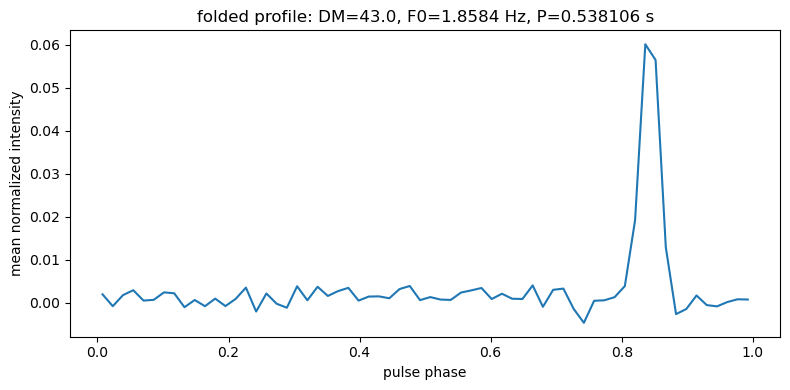

In [82]:
df = pd.read_csv("cluster_candidates.csv")
candidate_f0 = df["weighted_avg_f0"].iloc[0]

candidate_dm = 43.0      

candidate_period = 1 / candidate_f0

print(f"candidate DM = {candidate_dm}")
print(f"candidate F0 = {candidate_f0} Hz")
print(f"candidate period = {candidate_period} s")

# dedisperse at DM
dedisp_candidate, shifts_candidate = dedisperse(
    data_masked,
    freqs_mhz,
    candidate_dm,
    dt,
    ref_freq
)

# collapse over freq
series_candidate = t_series_1D(dedisp_candidate)

# clean 1D time series (get rid of nans)
med = np.nanmedian(series_candidate)
series_candidate = np.where(np.isnan(series_candidate), med, series_candidate)
series_candidate = series_candidate - np.median(series_candidate)

# match time axis
times_candidate_s = np.arange(len(series_candidate)) * dt

# fold
nbins = 64 # use 32 if signal too weak or up 128 if strong
period = 1 / candidate_f0

# PHASE
phase = (times_candidate_s % period) / period

bins = np.linspace(0, 1, nbins + 1)
folded = np.full(nbins, np.nan)

for b in range(nbins):
    in_bin = (phase >= bins[b]) & (phase < bins[b + 1])
    if np.any(in_bin):
        folded[b] = np.nanmean(series_candidate[in_bin])

phase_centers = 0.5 * (bins[:-1] + bins[1:])

plt.figure(figsize=(8, 4))
plt.plot(phase_centers, folded)
plt.xlabel("pulse phase")
plt.ylabel("mean normalized intensity")
plt.title(
    f"folded profile: DM={candidate_dm:.1f}, "
    f"F0={candidate_f0:.4f} Hz, P={period:.6f} s"
)
plt.tight_layout()
plt.savefig("folded_profile_phase.png")
plt.show()